In [2]:

import numpy as np

#load the data
exo_df = np.load('./data/upb.npy')
print(exo_df.shape)

(770, 1894, 3)


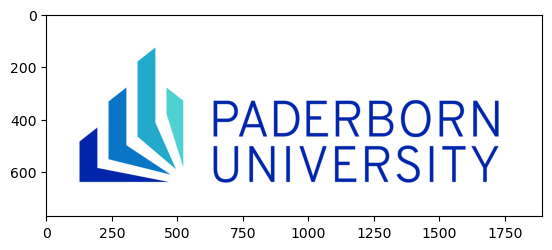

In [3]:
import matplotlib.pyplot as pl


pl.imshow(exo_df)

In [4]:
exo_df.size

4375140

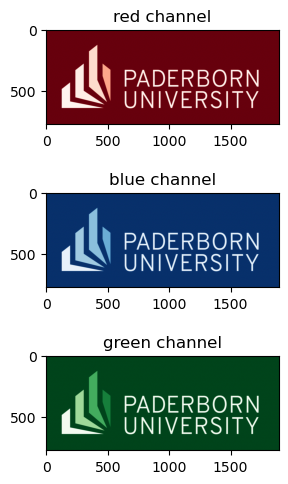

In [5]:
# Creating a subplot for

# We obtain the different channels of the image 
red_c = exo_df[:, :, 0]
green_c = exo_df[:, :, 1]
blue_c = exo_df[:, :, 2]

#  we create a figure for our subplots
figure, axes = pl.subplots(nrows=3, figsize=(3,6))

# we plot the red channel in in the subplot
axes[0].imshow(red_c, cmap='Reds')
axes[0].set_title('red channel')

axes[1].imshow(blue_c, cmap='Blues')
axes[1].set_title('blue channel')

axes[2].imshow(green_c, cmap='Greens')
axes[2].set_title('green channel')
pl.show()

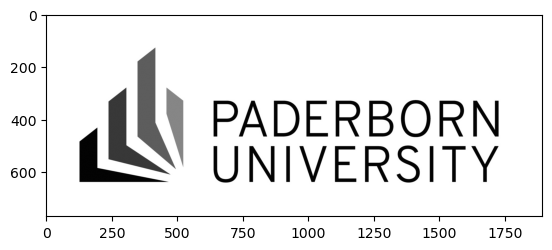

In [6]:
# gray scale image
gsi = exo_df.mean(axis=2)

pl.imshow(gsi, cmap='gray')


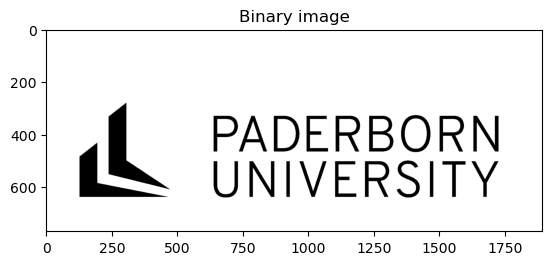

In [7]:
# The binary image of the gray scale by copying the the gsi arry
#  and casting to a specified type based on a condition

binary_image = (gsi >= 128).astype(int)
pl.imshow(binary_image, cmap='gray')
pl.title('Binary image')
pl.show()


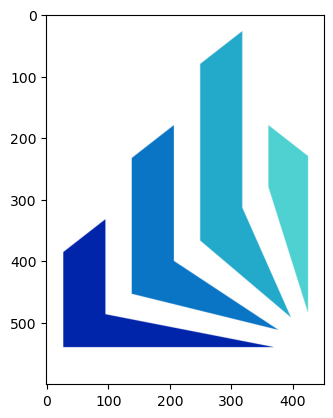

In [8]:
# cropping the image according to certain specified regions
x1, y1 = 100, 100
x2, y2 = 550, 700

cropped_image = exo_df[y1:y2, x1:x2]
pl.imshow(cropped_image)


In [9]:
import pandas as pd

In [10]:
# Read the reservation dataset and display the shape
df = pd.read_csv('./data/Hotel Reservations.csv', engine='python')
df.shape[0] # number of rows

36275

In [11]:
# displaying the first 5 rows of the datasset
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [12]:
# Drop ping the Booking_ID column
df.drop(columns=['Booking_ID'], inplace=True)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [13]:
# removing the columns where no_of_adults  < 1 
df_more_adults = df[df['no_of_adults'] >= 1]
df_more_adults.shape[0]

df.shape[0] - df_more_adults.shape[0] # number of rows dropped

139

In [14]:
# Mappring the booking status column to 0 and 1 depending on the status
df['booking_status'] = df['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})
df.head()



,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,0
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,1
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,1
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,1


In [15]:
total_bookings = df.shape[0]

no_canceled_bookings = len(df[df['booking_status'] == 1])
percentage_canceled = (no_canceled_bookings / total_bookings) * 100

print(f'percentage of canceled bookings {percentage_canceled: .2f}%')


percentage of canceled bookings  32.76%


In [16]:
months = df['arrival_month']
bookings_by_month = df.groupby('arrival_month').size()

bookings_by_month.idxmax()

10

In [20]:
# Checking number of solo travelers and number of familites
# Families total booking for nights
#  Assuming that a family has at least one child
pd.options.mode.chained_assignment = None # ignore warnings

families = df[df['no_of_children'] > 0 ]
solo_travellers = df[df['no_of_children'] == 0]


families['total_nights'] = families['no_of_week_nights'] + families['no_of_weekend_nights']
average_family_nights = families['total_nights'].mean()

solo_travellers['total_nights'] = solo_travellers['no_of_week_nights'] + solo_travellers['no_of_weekend_nights']
average_solo_nights = solo_travellers['total_nights'].mean()

print(average_family_nights > average_solo_nights)



True


In [21]:
# Assuming that the rate of cancelation is the proportion cancelation to the total 
# booking in each segement
online_market_segment = df[df['market_segment_type'] == 'Online']
offline_market_segment = df[df['market_segment_type'] == 'Offline']


cancelation_rate_online = online_market_segment['no_of_previous_cancellations'].sum() / online_market_segment.shape[0]
cancelation_rate_offline = offline_market_segment['no_of_previous_cancellations'].sum() / offline_market_segment.shape[0]

round(cancelation_rate_offline, 3), round(cancelation_rate_online, 3)


(0.011, 0.013)

Text(0.5, 0, 'Lead time')

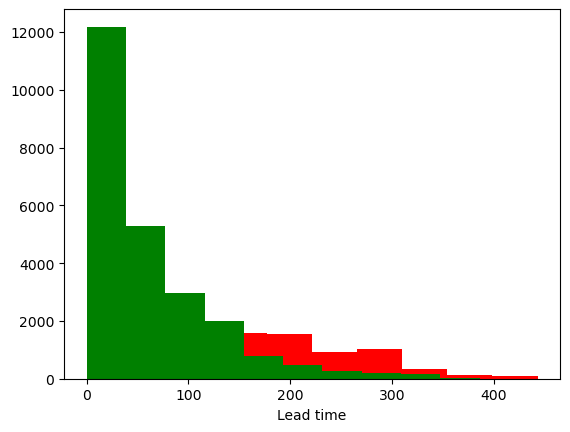

In [22]:
# Plotting histogram of lead time seperated by booking status

lead_time_canceled = df[df['booking_status'] == 1]['lead_time']
lead_time_not_canceled = df[df['booking_status'] == 0]['lead_time']

pl.hist(lead_time_canceled, bins=10, label='Canceled', color='red')

pl.hist(lead_time_not_canceled, bins=10, label='Canceled', color='green')
pl.xlabel('Lead time')

In [24]:
from sklearn.preprocessing import OneHotEncoder

# Encoding will be done to the columns": type_of_meal_plan, room_type_reserved, market_segment_type
categorical_columns = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type',
                       'booking_status' ]

encoder = OneHotEncoder(sparse_output=False)
encoded_series = encoder.fit_transform(df[categorical_columns])

# Encoded columns is a series, so we need to convert it to a dataframe
encoded_columns = pd.DataFrame(encoded_series, columns=encoder.get_feature_names_out(categorical_columns))
# Reset indices of the encoded columns
encoded_columns.reset_index(drop=True, inplace=True)

# Add encoded rows to the original dataframe
df_with_encoded_columns = pd.concat([df.drop(columns=categorical_columns).reset_index(drop=True), encoded_columns], axis=1)

df_with_encoded_columns.head()


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_0,booking_status_1
0,2,0,1,2,0,224,2017,10,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,2,0,2,3,0,5,2018,11,6,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1,0,2,1,0,1,2018,2,28,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2,0,0,2,0,211,2018,5,20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,2,0,1,1,0,48,2018,4,11,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [28]:

# Normalizing the numerical columns
from sklearn.preprocessing import MinMaxScaler
numerical_columns = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
                     'no_of_week_nights', 'required_car_parking_space', 'lead_time',
                     'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
                     'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
                     'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 1',
                     'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
                     'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 1',
                     'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3',
                     'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5',
                     'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7',
                     'market_segment_type_Aviation', 'market_segment_type_Complementary',
                     'market_segment_type_Corporate', 'market_segment_type_Offline',
                     'market_segment_type_Online', 'booking_status_0', 'booking_status_1']
scaler = MinMaxScaler()

# fit the scaler to the numerical columns
scaled_numerical_columns = pd.DataFrame(scaler.fit_transform(df_with_encoded_columns[numerical_columns]), columns=numerical_columns)

scaled_numerical_columns.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_0,booking_status_1
0,0.50,0.0,0.142857,0.117647,0.0,0.505643,0.0,0.818182,0.033333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.50,0.0,0.285714,0.176471,0.0,0.011287,1.0,0.909091,0.166667,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.25,0.0,0.285714,0.058824,0.0,0.002257,1.0,0.090909,0.900000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.50,0.0,0.000000,0.117647,0.0,0.476298,1.0,0.363636,0.633333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.50,0.0,0.142857,0.058824,0.0,0.108352,1.0,0.272727,0.333333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [29]:
# Creating and visualize the correlation matrix
# The Booking_ID colummn is dropped as it is not used

corr_matrix = scaled_numerical_columns.corr()

print(corr_matrix.head)

<bound method NDFrame.head of                                       no_of_adults  no_of_children  \
no_of_adults                              1.000000       -0.019787   
no_of_children                           -0.019787        1.000000   
no_of_weekend_nights                      0.103316        0.029478   
no_of_week_nights                         0.105622        0.024398   
required_car_parking_space                0.011429        0.034244   
lead_time                                 0.097287       -0.047091   
arrival_year                              0.076719        0.045983   
arrival_month                             0.021841       -0.003076   
arrival_date                              0.026338        0.025482   
repeated_guest                           -0.192277       -0.036348   
no_of_previous_cancellations             -0.047426       -0.016390   
no_of_previous_bookings_not_canceled     -0.119166       -0.021189   
avg_price_per_room                        0.296886        0.

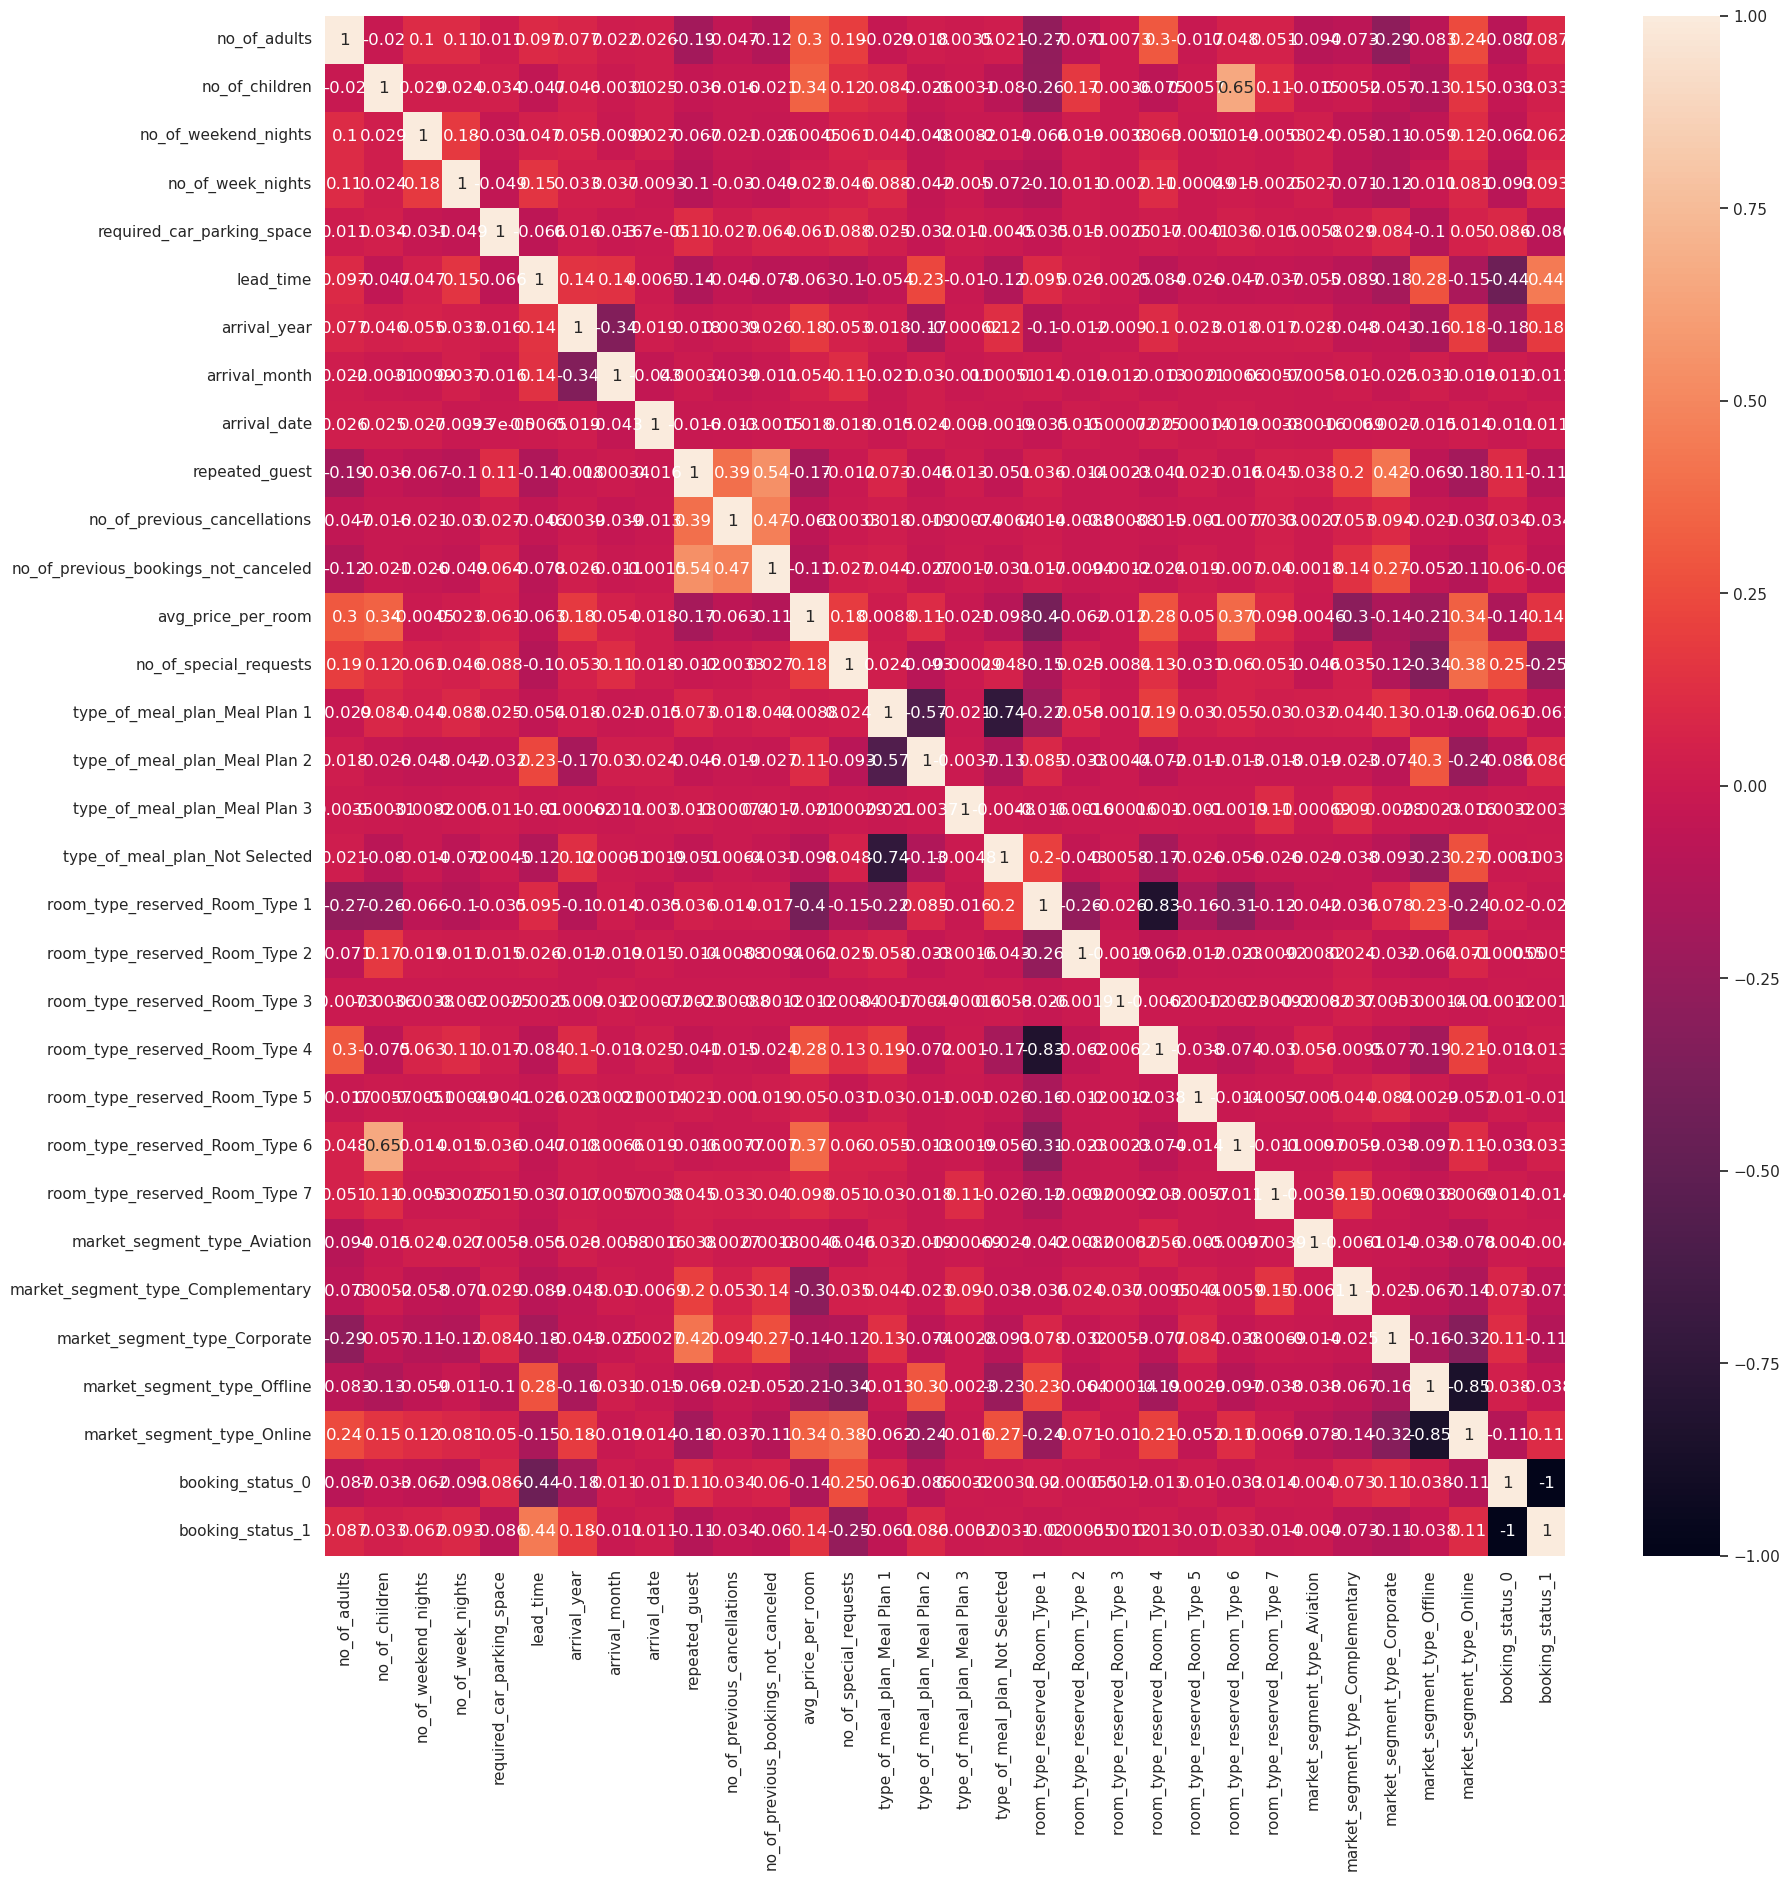

In [31]:
import seaborn as sn

sn.heatmap(corr_matrix, annot=True)
sn.set(rc={'figure.figsize':(20,5)})
pl.show()